In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

from src.loader import load_files
from src.preprocessor import normalize_train_test
from src.features import extract_features

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

In [2]:
# Загружаем сырые (ненормализованные) данные
print("Loading raw data...")
df_raw = load_files(min_sensors=2)
print(f"Total rows: {len(df_raw):,}")
print(f"Unique source files: {df_raw['source'].nunique()}")

# Split по файлам ДО любой нормализации
sources = df_raw["source"].unique()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
src_train_idx, src_test_idx = next(gss.split(sources, groups=sources))
train_sources = set(sources[src_train_idx])
test_sources  = set(sources[src_test_idx])

# Проверка — overlap должен быть 0
overlap = train_sources & test_sources
print(f"\nTrain files: {len(train_sources)}")
print(f"Test files:  {len(test_sources)}")
print(f"Overlap:     {len(overlap)}")  # MUST be 0

df_train_raw = df_raw[df_raw["source"].isin(train_sources)].copy()
df_test_raw  = df_raw[df_raw["source"].isin(test_sources)].copy()

Loading raw data...
  [0] Normal: Loaded 10 files
  [3] DHSV Failure: Loaded 10 files
  [4] Severe Slugging: Loaded 10 files
  [7] Scaling PCK: Loaded 10 files
  [9] Hydrate: Loaded 10 files
Total rows: 3,653,142
Unique source files: 50

Train files: 40
Test files:  10
Overlap:     0


In [3]:
# Scaler обучается ТОЛЬКО на train-normal строках
print("Normalizing (scaler fitted on train-normal only)...")
df_train_norm, df_test_norm, scaler = normalize_train_test(
    df_train_raw, df_test_raw,
    scaler_path="../outputs/models/scaler.pkl",
)

# Feature extraction отдельно для train и test
print("\nExtracting features...")
print("  Train...")
df_feat_train = extract_features(df_train_norm)
print("  Test...")
df_feat_test  = extract_features(df_test_norm)

feature_cols = [c for c in df_feat_train.columns
                if c not in ("label", "event_type", "source")]

print(f"\nFeatures: {len(feature_cols)}")
print(f"Train: {len(df_feat_train):,} windows | "
      f"balance: {df_feat_train['label'].value_counts().to_dict()}")
print(f"Test:  {len(df_feat_test):,} windows  | "
      f"balance: {df_feat_test['label'].value_counts().to_dict()}")

Normalizing (scaler fitted on train-normal only)...
Scaler fitted on 723,846 normal rows from train set only
Scaler saved: ../outputs/models/scaler.pkl

Extracting features...
  Train...
Dataframes extracted: 80,938
Signs: 31
  Test...
Dataframes extracted: 40,758
Signs: 31

Features: 30
Train: 80,938 windows | balance: {1: 56843, 0: 24095}
Test:  40,758 windows  | balance: {1: 34243, 0: 6515}


In [4]:
feature_cols = [c for c in df_feat_train.columns
                if c not in ("label", "event_type", "source")]

for name, df in [("Train", df_feat_train), ("Test", df_feat_test)]:
    all_zero = (df[feature_cols] == 0).all(axis=1).sum()
    nan_pct  = df[feature_cols].isnull().mean() * 100
    print(f"[{name}] Fully zero rows: {all_zero} ({all_zero/len(df)*100:.1f}%)")
    missing = nan_pct[nan_pct > 0].sort_values(ascending=False)
    if len(missing):
        print(f"[{name}] Features with NaN (%):\n{missing}\n")
    else:
        print(f"[{name}] No NaN features\n")

[Train] Fully zero rows: 0 (0.0%)
[Train] No NaN features

[Test] Fully zero rows: 0 (0.0%)
[Test] No NaN features



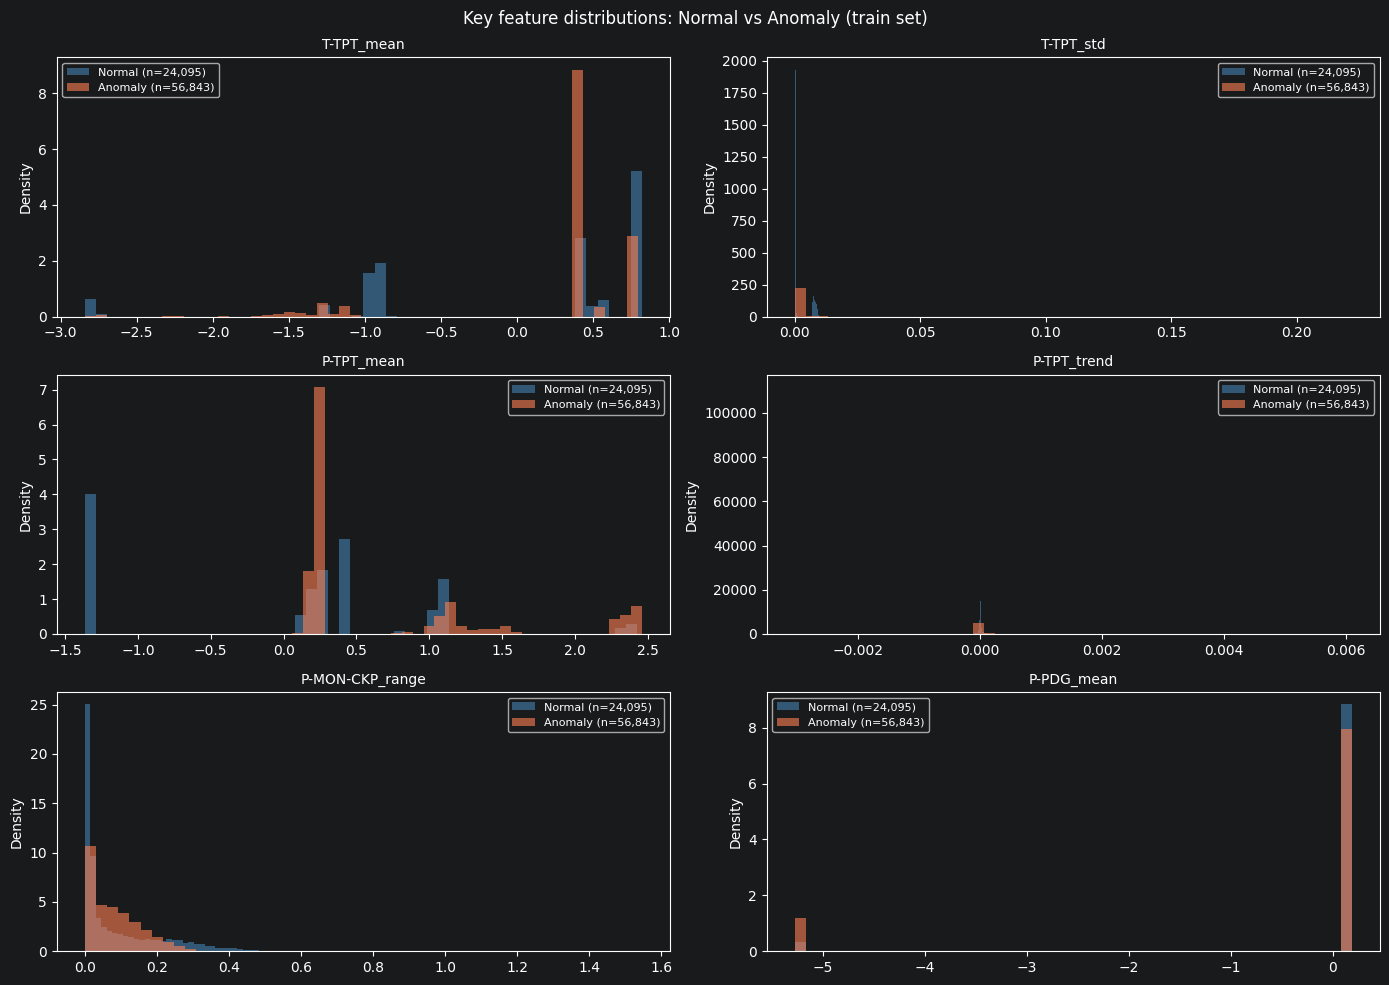

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

key_features = [
    "T-TPT_mean", "T-TPT_std",
    "P-TPT_mean", "P-TPT_trend",
    "P-MON-CKP_range", "P-PDG_mean"
]

for ax, feat in zip(axes, key_features):
    if feat not in df_feat_train.columns:
        ax.set_visible(False)
        continue

    normal  = df_feat_train[df_feat_train["label"] == 0][feat]
    anomaly = df_feat_train[df_feat_train["label"] == 1][feat]

    ax.hist(normal,  bins=50, alpha=0.6, color="steelblue",
            label=f"Normal (n={len(normal):,})",  density=True)
    ax.hist(anomaly, bins=50, alpha=0.6, color="coral",
            label=f"Anomaly (n={len(anomaly):,})", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

plt.suptitle("Key feature distributions: Normal vs Anomaly (train set)", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_distributions.png", dpi=150)
plt.show()

In [6]:
TRAIN_PATH = "../outputs/features_train.parquet"
TEST_PATH  = "../outputs/features_test.parquet"

df_feat_train.to_parquet(TRAIN_PATH, index=False)
df_feat_test.to_parquet(TEST_PATH,   index=False)

for path, df in [(TRAIN_PATH, df_feat_train), (TEST_PATH, df_feat_test)]:
    size_mb = Path(path).stat().st_size / 1024 / 1024
    print(f"Saved: {path}  |  {size_mb:.1f} MB  |  {len(df):,} windows x {len(feature_cols)} features")

print("\nDone. Next: 03_1_modeling_basic.ipynb")

Saved: ../outputs/features_train.parquet  |  12.0 MB  |  80,938 windows x 30 features
Saved: ../outputs/features_test.parquet  |  6.1 MB  |  40,758 windows x 30 features

Done. Next: 03_1_modeling_basic.ipynb
